# 13 - Intermediate Fusion Transfer Learning (ResNet18 + FCNN - 7 Class)

**Tujuan:** Melatih model Intermediate Fusion dengan Transfer Learning yang menggabungkan fitur penampilan (ResNet18 pretrained) dan fitur geometrik (FCNN) di level fitur (feature-level) untuk pengenalan emosi.

**Catatan terminologi:** Arsitektur ini disebut **Intermediate Fusion** (Boulahia et al., 2021) karena fusi dilakukan di level representasi fitur yang diekstrak masing-masing subnetwork, bukan di level input (early fusion) maupun di level keputusan (late fusion). Istilah lain yang setara: *feature-level fusion* atau *middle fusion*. Ini **berbeda dengan hybrid fusion** yang menggabungkan dua atau lebih strategi fusi sekaligus.

**Menjawab RQ3:** *Bagaimana performa model multimodal Intermediate Fusion Transfer Learning (ResNet18 + FCNN) dalam pengenalan emosi mahasiswa pada konteks pembelajaran pemrograman menggunakan gabungan fitur penampilan dan fitur geometrik?*

**Arsitektur:**
- Image stream (ResNet18 pretrained): ResNet18 backbone → 256-dim feature vector
- Landmark stream (FCNN): 4 Dense layers → 128-dim feature vector
- Concatenate (384-dim) → Dense(512→256) → 7 classes

**3 Skenario Imbalance:**
- B1: Tanpa penanganan (baseline)
- B2: Dengan class weights (Cui et al., 2019)
- B3: Dengan class weights + augmentasi

## 1. Setup

In [1]:
import sys
import os
import json
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path

# Add project root to path
PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from training.models import IntermediateFusionTransfer
from training.utils import (
    EmotionMultimodalDataset, get_class_weights,
    train_model, full_evaluation,
    plot_training_history, plot_confusion_matrix, plot_per_class_f1
)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
Memory: 15.6 GB


In [2]:
# Config
DATASET_DIR = PROJECT_ROOT / "data" / "dataset"
DATASET_AUG_DIR = PROJECT_ROOT / "data" / "dataset_augmented"
OUTPUT_DIR = PROJECT_ROOT / "models" / "intermediate_fusion_transfer"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BATCH_SIZE = 16
EPOCHS = 80
LR = 0.00005
PATIENCE = 25
NUM_CLASSES = 7

EMOTIONS = ["neutral", "happy", "sad", "angry", "fearful", "disgusted", "surprised"]
print(f"Dataset: {DATASET_DIR}")
print(f"Output: {OUTPUT_DIR}")

Dataset: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset
Output: /home/bs000716/MOTHER-TANK/TRAIN/models/intermediate_fusion_transfer


## 2. Load Data

In [3]:
from torch.utils.data import DataLoader
from collections import Counter

def load_dataloaders(dataset_dir, batch_size=16):
    """Load train/val/test dataloaders for multimodal (images + landmarks)."""
    train_ds = EmotionMultimodalDataset(
        dataset_dir / "X_train_images.npy",
        dataset_dir / "X_train_landmarks.npy",
        dataset_dir / "y_train.npy"
    )
    val_ds = EmotionMultimodalDataset(
        dataset_dir / "X_val_images.npy",
        dataset_dir / "X_val_landmarks.npy",
        dataset_dir / "y_val.npy"
    )
    test_ds = EmotionMultimodalDataset(
        dataset_dir / "X_test_images.npy",
        dataset_dir / "X_test_landmarks.npy",
        dataset_dir / "y_test.npy"
    )

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    # Print info
    y_train = np.load(dataset_dir / "y_train.npy")
    counts = Counter(y_train.tolist())
    print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")
    print(f"Train distribution:")
    for i, emo in enumerate(EMOTIONS):
        print(f"  {emo:>10s}: {counts.get(i, 0)}")

    return train_loader, val_loader, test_loader

# Load original dataset
train_loader, val_loader, test_loader = load_dataloaders(DATASET_DIR, BATCH_SIZE)

Train: 7064 | Val: 1174 | Test: 1656
Train distribution:
     neutral: 5678
       happy: 751
         sad: 490
       angry: 48
     fearful: 8
   disgusted: 19
   surprised: 70


## 3. Skenario B1: Baseline (Tanpa Class Weights)

In [4]:
# B1: Baseline - no class weights
model_b1 = IntermediateFusionTransfer(num_classes=NUM_CLASSES, landmark_dim=136, pretrained=True).to(device)
criterion_b1 = nn.CrossEntropyLoss()
optimizer_b1 = torch.optim.Adam(model_b1.parameters(), lr=LR)
scheduler_b1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_b1, mode="max", factor=0.5, patience=8, min_lr=1e-7
)

print(f"Model parameters: {sum(p.numel() for p in model_b1.parameters()):,}")
print("Training B1 (baseline)...")
history_b1, best_epoch_b1 = train_model(
    model_b1, train_loader, val_loader, criterion_b1, optimizer_b1, scheduler_b1,
    device, model_type="fusion", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "intermediate_tl_b1_baseline.pth")
)

Model parameters: 11,973,319
Training B1 (baseline)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.1527     0.6583     1.0286    0.9191   0.1645   0.000050  (26.6s)


     2      0.6101     0.8236     0.6784    0.9114   0.2558   0.000050  (26.3s)


     3      0.5118     0.8359     0.4231    0.9370   0.2771   0.000050  (26.4s)


     4      0.4464     0.8548     0.4188    0.9191   0.2568   0.000050  (26.4s)


...

    24      0.0457     0.9894     0.4288    0.9063   0.2500   0.000013  (26.3s)


    25      0.0447     0.9888     0.3581    0.9302   0.2604   0.000013  (26.3s)


    26      0.0383     0.9912     0.3939    0.9114   0.2491   0.000013  (26.3s)


    27      0.0399     0.9904     0.4028    0.9276   0.2699   0.000013  (26.3s)


    28      0.0373     0.9904     0.4273    0.8995   0.2456   0.000013  (26.3s)

Early stopping at epoch 28. Best epoch: 3 (val_f1=0.2771)

Best: epoch 3, val_acc=0.9370, val_f1=0.2771
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/intermediate_fusion_transfer/intermediate_tl_b1_baseline.pth


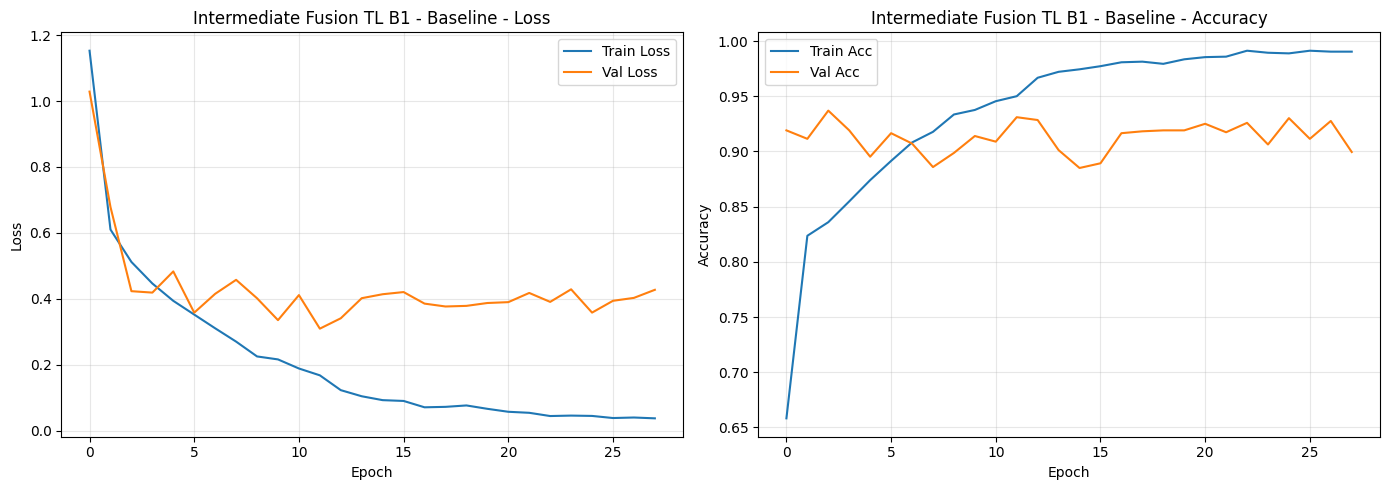

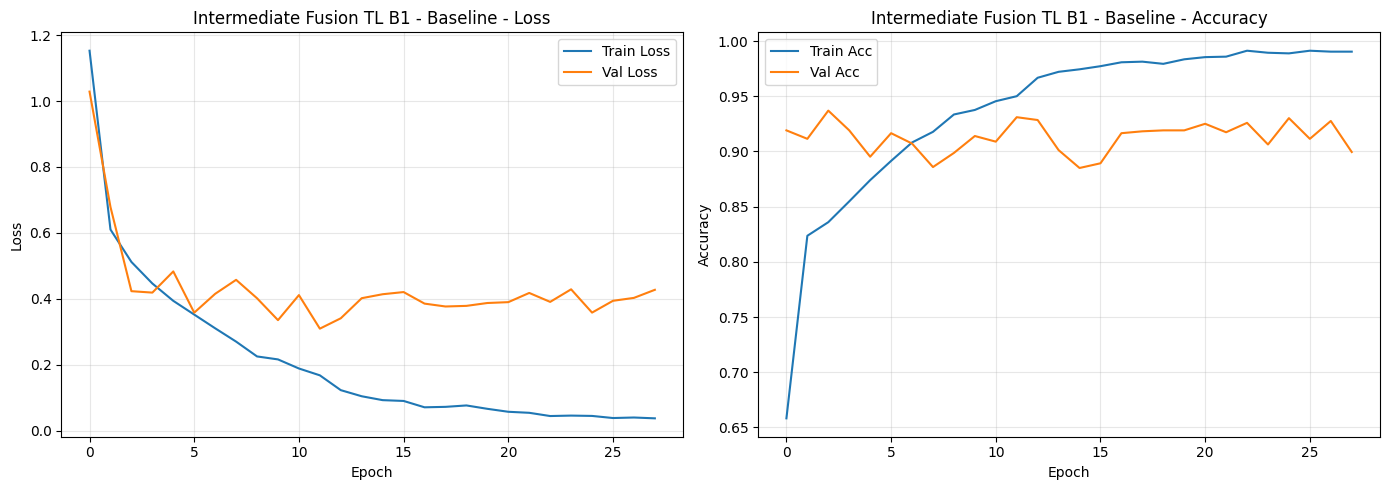

In [5]:
plot_training_history(history_b1, "Intermediate Fusion TL B1 - Baseline")

EVALUASI B1 - BASELINE


Test Loss: 0.4047
Test Accuracy: 0.9457
Test Macro F1: 0.2322
Test Weighted F1: 0.9487

Classification Report:
              precision    recall  f1-score   support

     neutral       0.98      0.97      0.98      1588
       happy       0.07      0.30      0.11        10
         sad       0.56      0.53      0.54        38
       angry       0.00      0.00      0.00        13
     fearful       0.00      0.00      0.00         1
   disgusted       0.00      0.00      0.00         3
   surprised       0.00      0.00      0.00         3

    accuracy                           0.95      1656
   macro avg       0.23      0.26      0.23      1656
weighted avg       0.95      0.95      0.95      1656



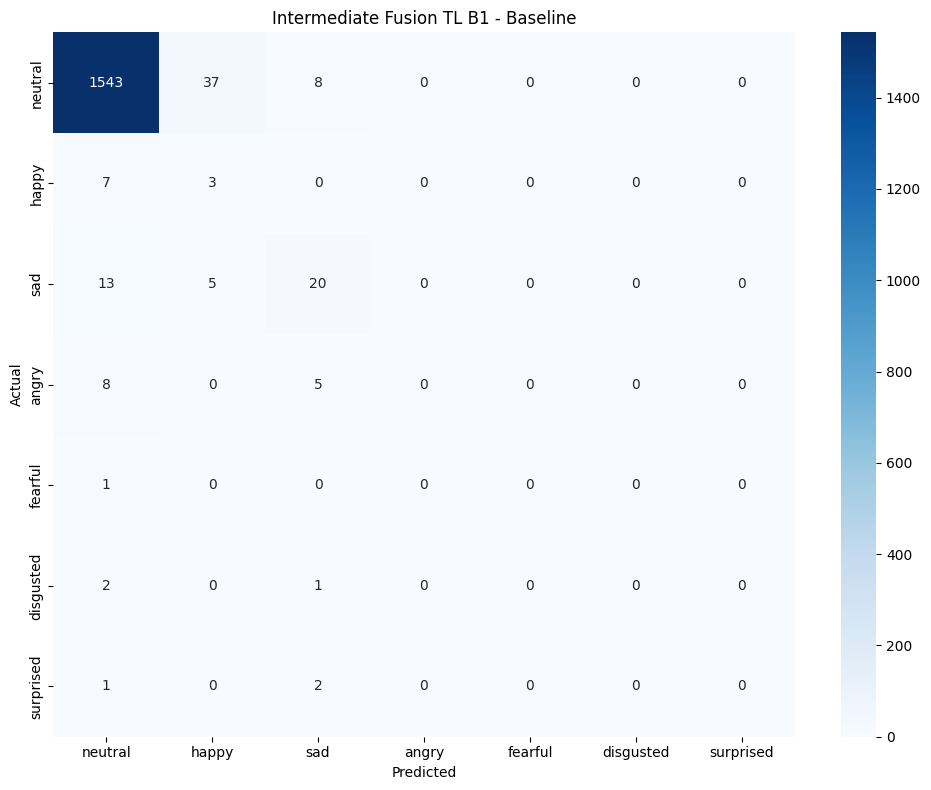

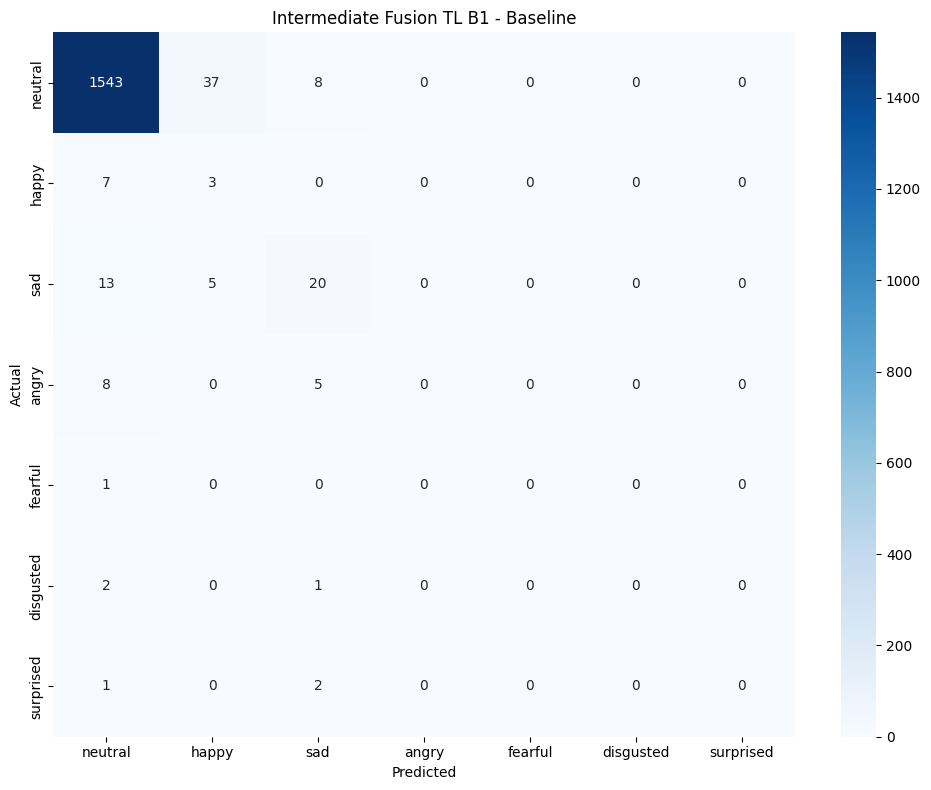

In [6]:
# Evaluate B1 on test set
print("=" * 60)
print("EVALUASI B1 - BASELINE")
print("=" * 60)
results_b1 = full_evaluation(model_b1, test_loader, criterion_b1, device, "fusion")
plot_confusion_matrix(results_b1["confusion_matrix"], "Intermediate Fusion TL B1 - Baseline")

## 4. Skenario B2: Dengan Class Weights

In [7]:
# B2: With class weights (Cui et al., 2019)
weights = get_class_weights(DATASET_DIR, device)
print(f"Class weights: {weights}")

model_b2 = IntermediateFusionTransfer(num_classes=NUM_CLASSES, landmark_dim=136, pretrained=True).to(device)
criterion_b2 = nn.CrossEntropyLoss(weight=weights)
optimizer_b2 = torch.optim.Adam(model_b2.parameters(), lr=LR)
scheduler_b2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_b2, mode="max", factor=0.5, patience=8, min_lr=1e-7
)

print("\nTraining B2 (class weights)...")
history_b2, best_epoch_b2 = train_model(
    model_b2, train_loader, val_loader, criterion_b2, optimizer_b2, scheduler_b2,
    device, model_type="fusion", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "intermediate_tl_b2_weighted.pth")
)

Class weights: tensor([  1.0000,   1.8865,   2.5717,  21.2542, 125.0103,  52.9257,  14.7340],
       device='cuda:0')



Training B2 (class weights)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.6770     0.4792     1.4151    0.9174   0.1795   0.000050  (26.3s)


     2      1.2513     0.7793     1.1905    0.8612   0.2019   0.000050  (26.3s)


     3      1.0702     0.7978     1.0333    0.8773   0.2445   0.000050  (26.3s)


...

    48      0.0140     0.9984     1.0613    0.9438   0.2847   0.000006  (26.3s)


    49      0.0157     0.9980     1.1427    0.9404   0.2758   0.000006  (26.4s)


    50      0.0105     0.9993     1.1026    0.9412   0.2802   0.000006  (26.4s)


    51      0.0120     0.9993     1.0641    0.9438   0.2951   0.000006  (26.3s)


    52      0.0116     0.9993     1.0361    0.9421   0.2901   0.000006  (26.3s)

Early stopping at epoch 52. Best epoch: 27 (val_f1=0.3307)

Best: epoch 27, val_acc=0.9404, val_f1=0.3307
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/intermediate_fusion_transfer/intermediate_tl_b2_weighted.pth


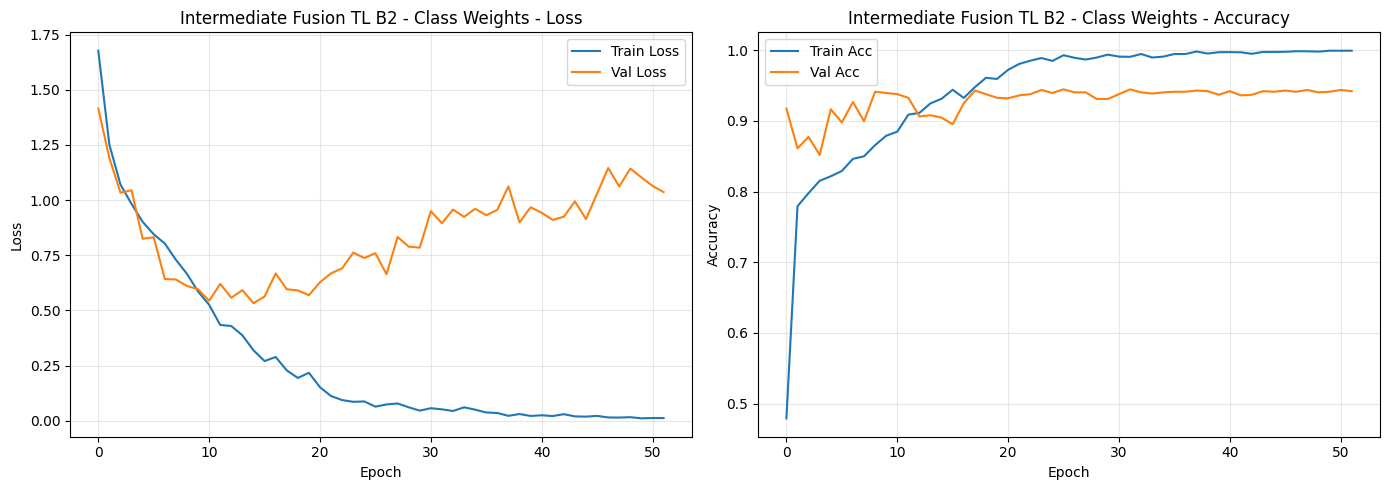

EVALUASI B2 - CLASS WEIGHTS


Test Loss: 0.5633
Test Accuracy: 0.9420
Test Macro F1: 0.1649
Test Weighted F1: 0.9387

Classification Report:
              precision    recall  f1-score   support

     neutral       0.97      0.98      0.98      1588
       happy       0.03      0.10      0.05        10
         sad       0.33      0.08      0.13        38
       angry       0.00      0.00      0.00        13
     fearful       0.00      0.00      0.00         1
   disgusted       0.00      0.00      0.00         3
   surprised       0.00      0.00      0.00         3

    accuracy                           0.94      1656
   macro avg       0.19      0.17      0.16      1656
weighted avg       0.94      0.94      0.94      1656



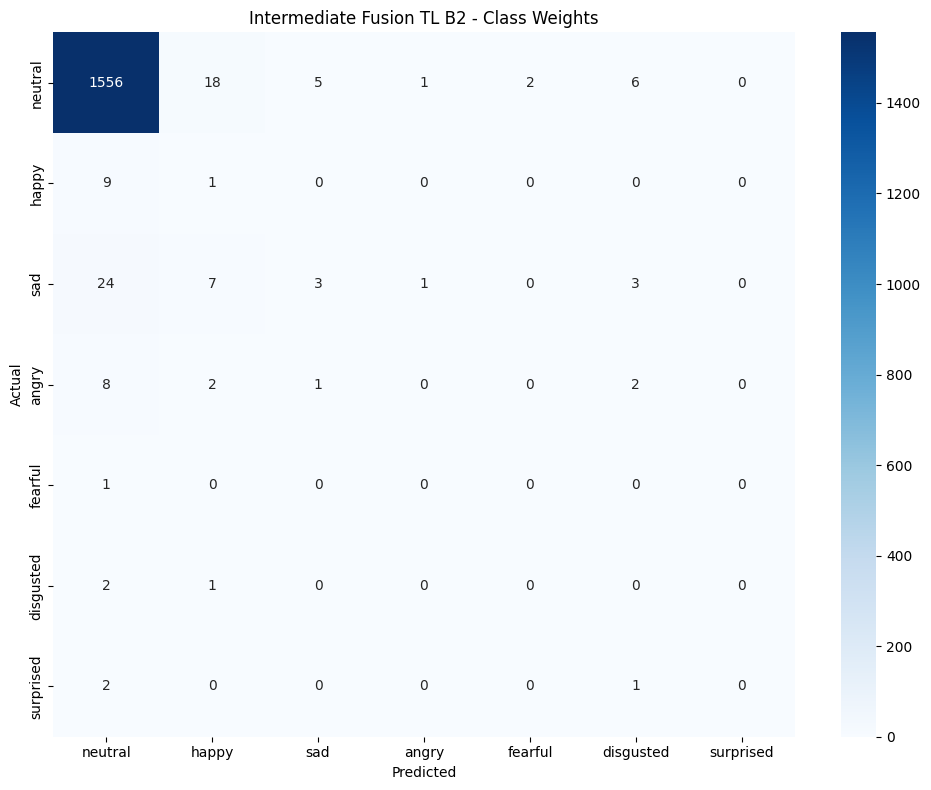

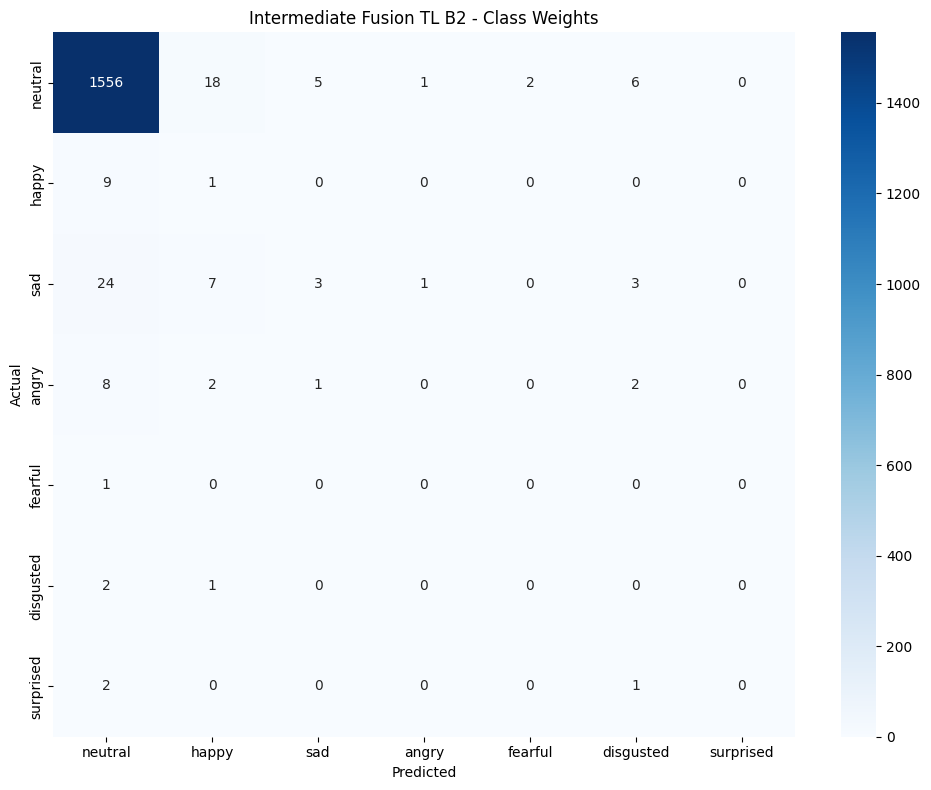

In [8]:
plot_training_history(history_b2, "Intermediate Fusion TL B2 - Class Weights")

print("=" * 60)
print("EVALUASI B2 - CLASS WEIGHTS")
print("=" * 60)
results_b2 = full_evaluation(model_b2, test_loader, criterion_b2, device, "fusion")
plot_confusion_matrix(results_b2["confusion_matrix"], "Intermediate Fusion TL B2 - Class Weights")

## 5. Skenario B3: Class Weights + Augmentasi

In [9]:
# B3: Class weights + augmented data
train_loader_aug, _, _ = load_dataloaders(DATASET_AUG_DIR, BATCH_SIZE)
weights_aug = get_class_weights(DATASET_AUG_DIR, device)
print(f"Augmented class weights: {weights_aug}")

model_b3 = IntermediateFusionTransfer(num_classes=NUM_CLASSES, landmark_dim=136, pretrained=True).to(device)
criterion_b3 = nn.CrossEntropyLoss(weight=weights_aug)
optimizer_b3 = torch.optim.Adam(model_b3.parameters(), lr=LR)
scheduler_b3 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_b3, mode="max", factor=0.5, patience=8, min_lr=1e-7
)

print("\nTraining B3 (class weights + augmentation)...")
history_b3, best_epoch_b3 = train_model(
    model_b3, train_loader_aug, val_loader, criterion_b3, optimizer_b3, scheduler_b3,
    device, model_type="fusion", epochs=EPOCHS, patience=PATIENCE,
    save_path=str(OUTPUT_DIR / "intermediate_tl_b3_augmented.pth")
)

Train: 7519 | Val: 1174 | Test: 1656
Train distribution:
     neutral: 5678
       happy: 751
         sad: 490
       angry: 150
     fearful: 150
   disgusted: 150
   surprised: 150
Augmented class weights: tensor([1.0000, 1.8865, 2.5717, 7.1514, 7.1514, 7.1514, 7.1514],
       device='cuda:0')



Training B3 (class weights + augmentation)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      1.6200     0.5679     1.3174    0.8262   0.1354   0.000050  (29.5s)


     2      1.2644     0.7388     1.0647    0.8083   0.1486   0.000050  (29.7s)


     3      1.0479     0.7712     0.8023    0.9225   0.2547   0.000050  (29.6s)


...

    33      0.0208     0.9961     0.7791    0.9302   0.2680   0.000013  (29.2s)


    34      0.0174     0.9979     0.8483    0.9336   0.2552   0.000013  (29.3s)


    35      0.0208     0.9968     0.8423    0.9319   0.2600   0.000013  (29.4s)


    36      0.0187     0.9967     0.7550    0.9267   0.2809   0.000013  (29.2s)


    37      0.0191     0.9967     0.9014    0.9370   0.2723   0.000013  (29.1s)

Early stopping at epoch 37. Best epoch: 12 (val_f1=0.2949)

Best: epoch 12, val_acc=0.9387, val_f1=0.2949
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/intermediate_fusion_transfer/intermediate_tl_b3_augmented.pth


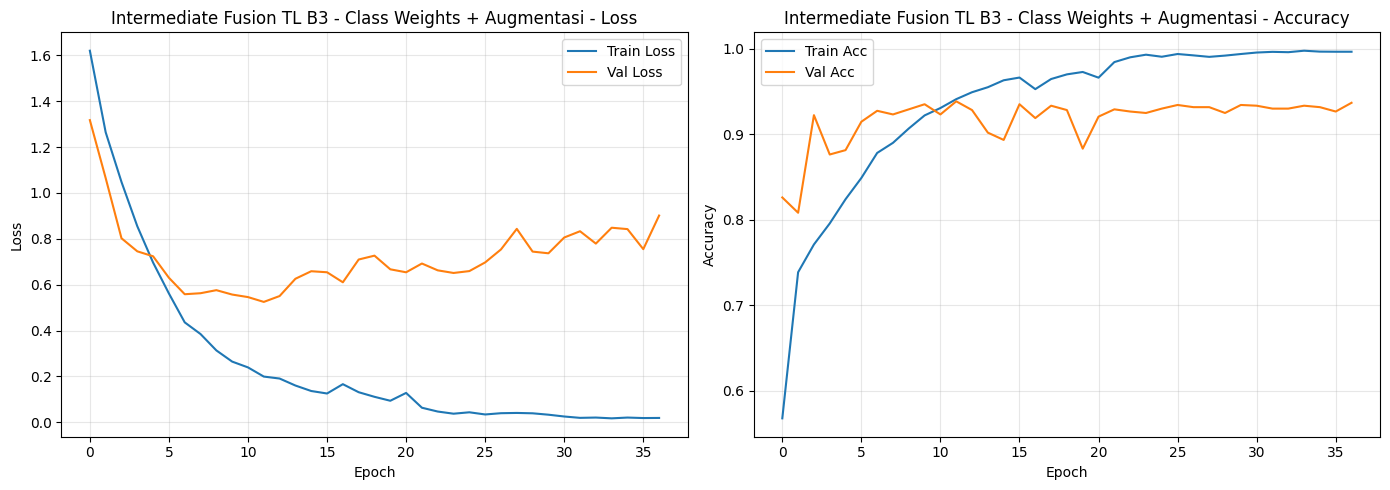

EVALUASI B3 - CLASS WEIGHTS + AUGMENTASI


Test Loss: 0.3742
Test Accuracy: 0.9511
Test Macro F1: 0.1888
Test Weighted F1: 0.9413

Classification Report:
              precision    recall  f1-score   support

     neutral       0.97      0.99      0.98      1588
       happy       0.25      0.10      0.14        10
         sad       0.38      0.08      0.13        38
       angry       0.07      0.08      0.07        13
     fearful       0.00      0.00      0.00         1
   disgusted       0.00      0.00      0.00         3
   surprised       0.00      0.00      0.00         3

    accuracy                           0.95      1656
   macro avg       0.24      0.18      0.19      1656
weighted avg       0.94      0.95      0.94      1656



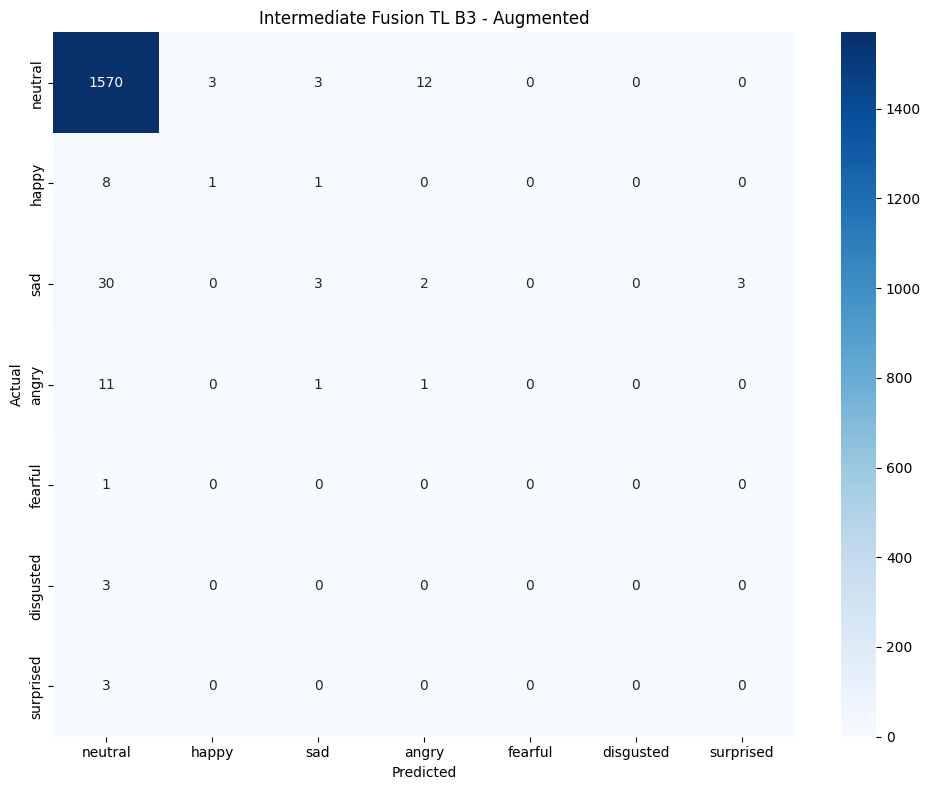

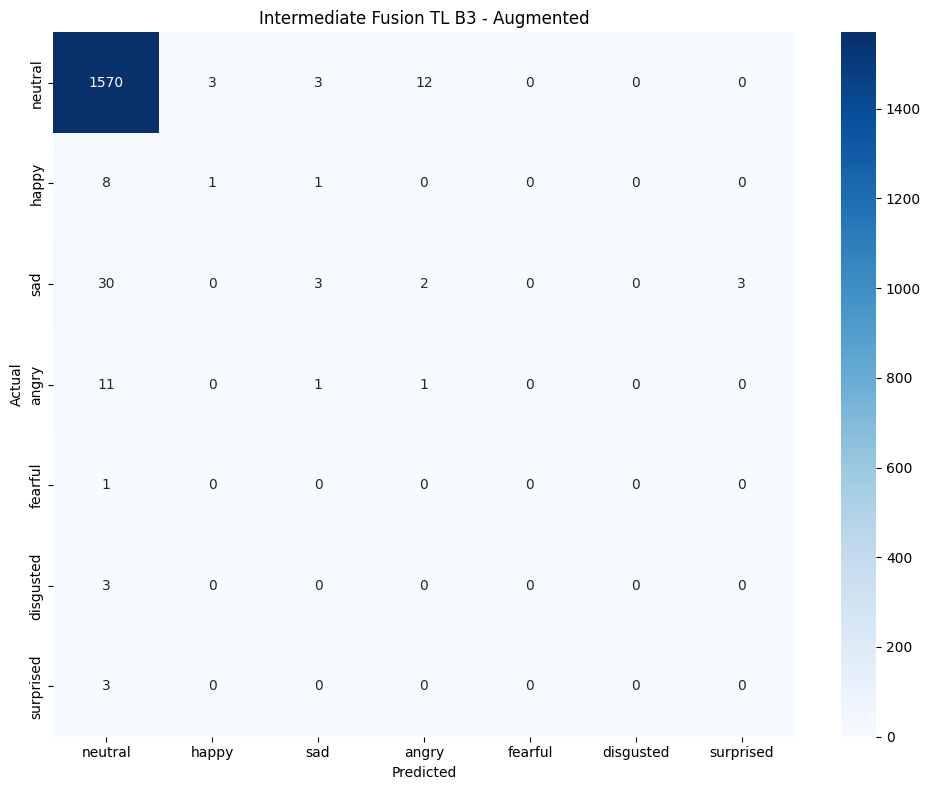

In [10]:
plot_training_history(history_b3, "Intermediate Fusion TL B3 - Class Weights + Augmentasi")

print("=" * 60)
print("EVALUASI B3 - CLASS WEIGHTS + AUGMENTASI")
print("=" * 60)
results_b3 = full_evaluation(model_b3, test_loader, criterion_b3, device, "fusion")
plot_confusion_matrix(results_b3["confusion_matrix"], "Intermediate Fusion TL B3 - Augmented")

## 6. Perbandingan 3 Skenario

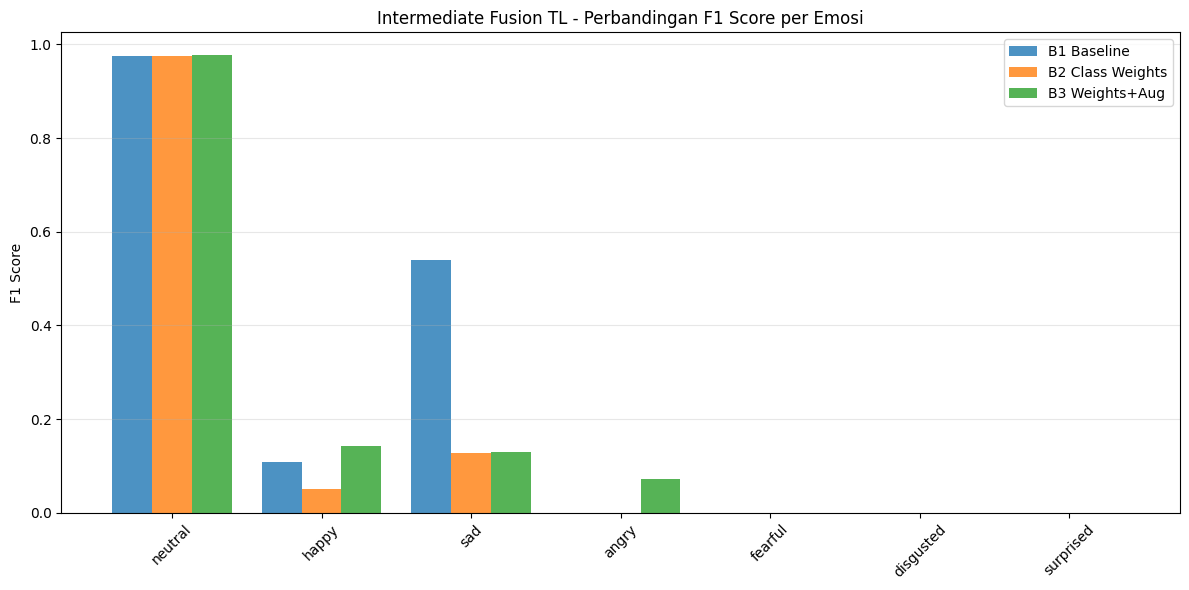

RINGKASAN INTERMEDIATE FUSION TRANSFER LEARNING - 3 SKENARIO
Skenario                    Accuracy   Macro F1  Weighted F1
----------------------------------------------------------------------
B1 Baseline                   0.9457     0.2322       0.9487
B2 Class Weights              0.9420     0.1649       0.9387
B3 Weights+Aug                0.9511     0.1888       0.9413


In [11]:
# Perbandingan per-class F1 score
all_results = {
    "B1 Baseline": results_b1,
    "B2 Class Weights": results_b2,
    "B3 Weights+Aug": results_b3,
}
plot_per_class_f1(all_results, "Intermediate Fusion TL - Perbandingan F1 Score per Emosi")

# Summary table
print("=" * 70)
print("RINGKASAN INTERMEDIATE FUSION TRANSFER LEARNING - 3 SKENARIO")
print("=" * 70)
print(f"{'Skenario':<25} {'Accuracy':>10} {'Macro F1':>10} {'Weighted F1':>12}")
print("-" * 70)
for name, r in all_results.items():
    print(f"{name:<25} {r['test_accuracy']:>10.4f} {r['test_macro_f1']:>10.4f} {r['test_weighted_f1']:>12.4f}")

## 7. Simpan Hasil

In [12]:
# Save results
fusion_results = {}
for name, r in all_results.items():
    fusion_results[name] = {
        "accuracy": float(r["test_accuracy"]),
        "macro_f1": float(r["test_macro_f1"]),
        "weighted_f1": float(r["test_weighted_f1"]),
    }
with open(OUTPUT_DIR / "intermediate_fusion_transfer_results.json", "w") as f:
    json.dump(fusion_results, f, indent=2)
print(f"Results saved to {OUTPUT_DIR / 'intermediate_fusion_transfer_results.json'}")

Results saved to /home/bs000716/MOTHER-TANK/TRAIN/models/intermediate_fusion_transfer/intermediate_fusion_transfer_results.json
